In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    transform=transform, 
    download=True
)
test_dataset = datasets.FashionMNIST(
    root='./data', 
    train=False, 
    transform=transform, 
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 1, 28, 28])


In [4]:
lb = labels.numpy()
print(lb)

[8 5 4 4 6 4 6 3 2 8 4 9 9 6 6 2 2 3 7 8 0 8 4 6 6 6 2 3 0 5 5 7]


C:\Users\user\AppData\Local\Temp\ipykernel_12704\2453447606.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


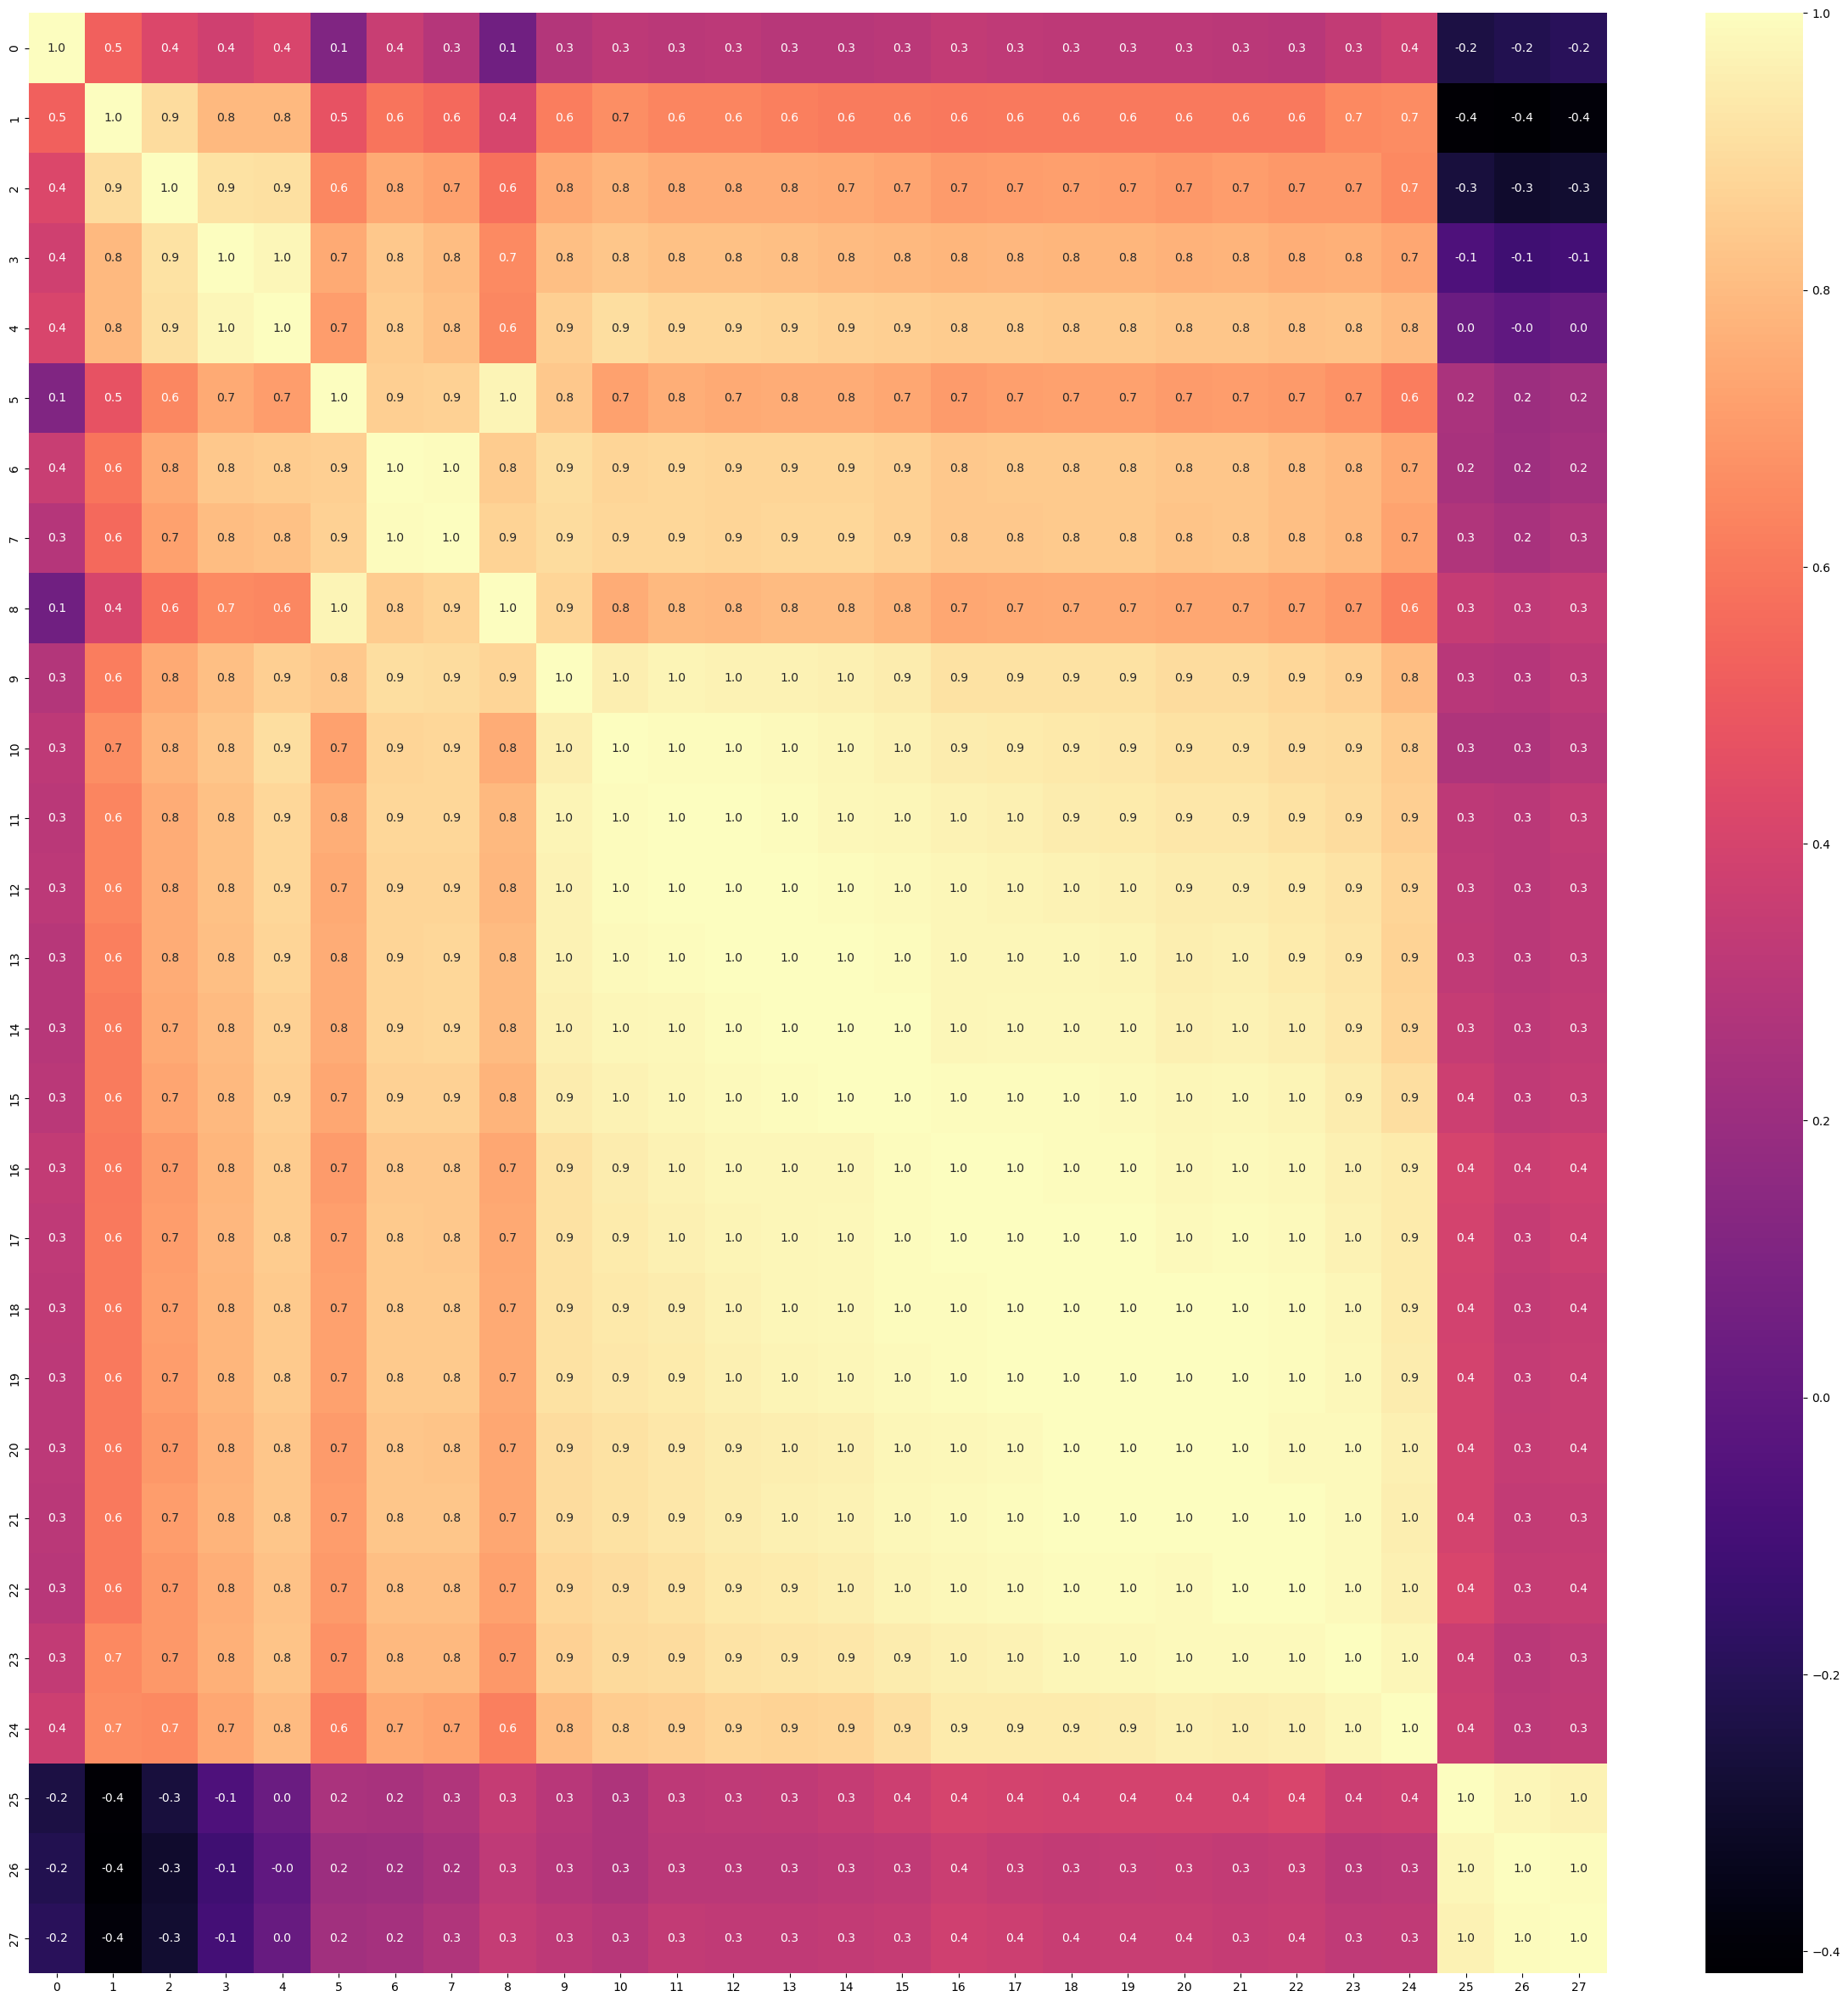

In [27]:
import seaborn as sns 
corr = torch.corrcoef(images[1].view(28, 28))
fig, ax = plt.subplots(1, 1, figsize=(30, 30))
sns.heatmap(corr, cmap='magma', annot=True, fmt='.1f')
fig.show()

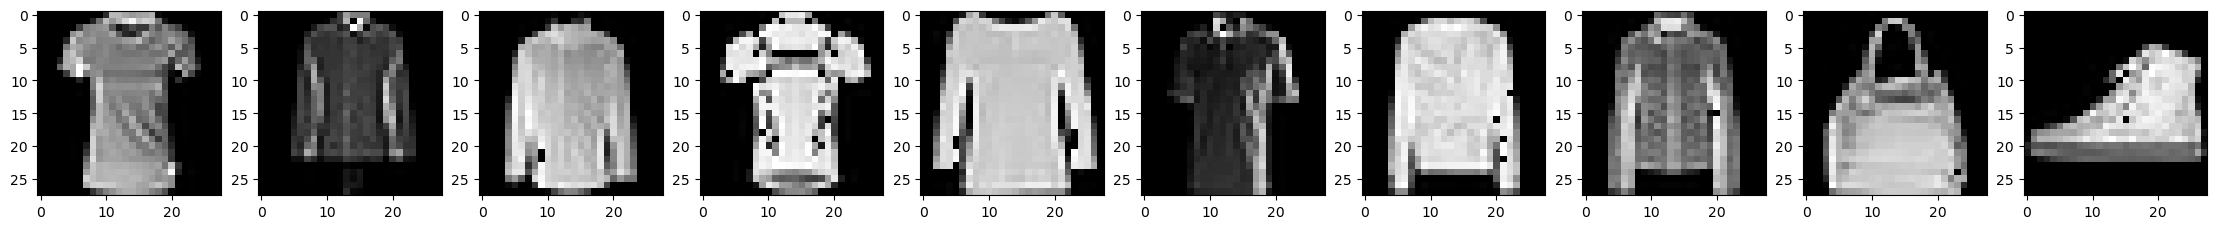

In [77]:
fig, axes = plt.subplots(1, 10, figsize = (28,28))
for i, img in enumerate(axes):
    _image = images[i,:,:,:]
    _image = _image.reshape(28,28)*256
    _image = _image.numpy()
    _image = _image.astype(np.uint8)
    ax = axes[i]
    ax.imshow(_image, cmap='gray')


In [28]:
class MLP(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        self.l2 = nn.Linear(hid, out)
    def forward(self, x):
        #print('x before view: ', x.shape)
        x = x.view(x.size(0), -1)
        #print('x after view: ', x.shape)
        out = self.l1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.l2(out)
        return out

In [41]:
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=True)
model.eval()  # Перевод модели в режим оценки (выключает dropout/batchnorm, если они есть)

with torch.no_grad():  # Отключаем расчет градиентов для экономии памяти и времени
    for images, labels in test_loader:
        test_outputs = model(images)
        # Находим индекс максимального значения в строке — это и есть предсказанный класс
        _, predicted_classes = torch.max(test_outputs, dim=1)

        # Считаем точность (Accuracy)
        correct = (predicted_classes == labels).sum().item()
        total = labels.size(0)
        accuracy = (correct / total) * 100

print(f"\nТочность (Accuracy) на тестовой выборке: {accuracy:.2f}%")


Точность (Accuracy) на тестовой выборке: 91.20%
